## 1. Environment Setup and Imports
First, load the necessary libraries for AFM data extraction, image processing, and deep learning segmentation.

In [ ]:
import pySPM
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, measure
# from tensorflow import keras # <-- Comment this out if you don't need to use the neural network model and it's giving you import errors

# Set plot defaults for consistency
plt.rcParams['figure.figsize'] = (12, 5)

: 

## 2. Loading AFM Data
We use `pySPM` to parse the Bruker `.spm` file. The target data is stored within the "Height Sensor" channel.

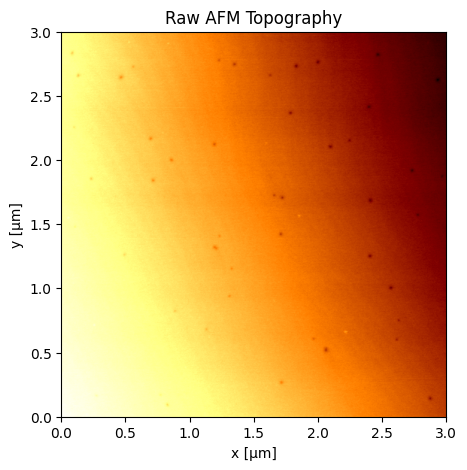

In [4]:
# Define file path (update with your actual file path)
file_path = "raw/fat_end_outside_L_03.0_00000.spm"

# Load the Bruker file
scan = pySPM.Bruker(file_path)

# Extract the height sensor channel
topo = scan.get_channel("Height Sensor")

# Plot raw data
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
topo.show(ax=ax, cmap='afmhot', title='Raw AFM Topography')
plt.show()

## 3. Basic Corrections
Raw AFM data often contains artifacts such as tilt, bow, row misalignments, and scanning scars. We will apply a standard correction pipeline:
1. **Flattening/Row Alignment:** Align rows by the median of differences.
2. **Scar Removal:** Filter out scan line artifacts with a threshold of 0.7.
3. **Plane Fit:** Level the data by subtracting a 2D fitted plane.

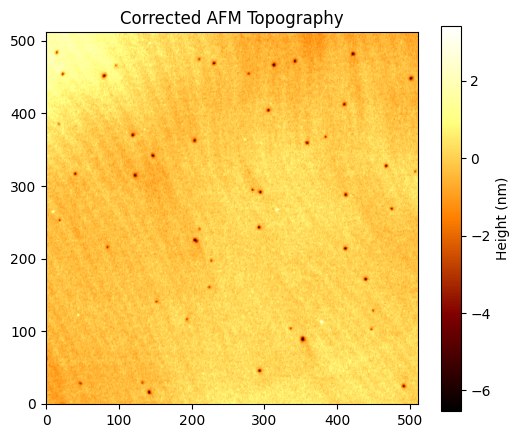

In [5]:
import copy

# Copy the original topography object
topo_corrected = copy.deepcopy(topo)

# 1. Row alignment
topo_corrected.correct_median_diff()

# 2. Scar removal
topo_corrected = topo_corrected.filter_scars_removal(0.7, inline=False)

# 3. 2D Plane fit
topo_corrected = topo_corrected.corr_fit2d(inline=False)

# Extract the processed pixel data as a NumPy array for segmentation
afm_data = topo_corrected.pixels

# Plot corrected data
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
plt.imshow(afm_data, cmap='afmhot', origin='lower')
plt.colorbar(label='Height (nm)')
plt.title('Corrected AFM Topography')
plt.show()

## 4. Segmentation via Local Thresholding
Threading dislocations appear as localized pits (dark spots). Global thresholding fails due to varying background heights, so we use local thresholding based on a moving window.

*   **Block Size:** 19 pixels. My scans are 3 x 3 um and 512 x 512 pixels, so this is equivalent to a 111 nm block size.
*   **Offset:** The offset adjusts sensitivity. We use an example offset of 1.287 nm.

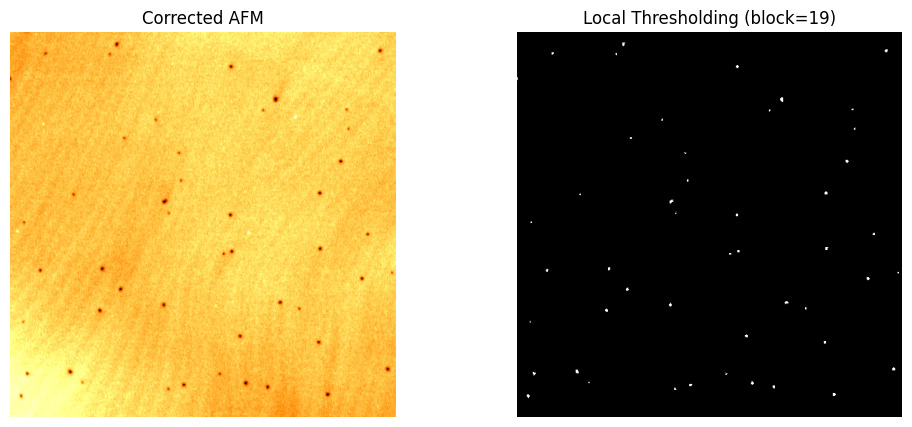

In [6]:
block_size = 19
offset_nm = 1.287 # Adjust this offset based on scan specifics

# Compute the local threshold map
local_thresh = filters.threshold_local(afm_data, block_size=block_size, offset=offset_nm)

# Generate binary mask where the data is below the local threshold (identifying pits)
binary_mask_thresh = afm_data < local_thresh

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(afm_data, cmap='afmhot')
ax1.set_title("Corrected AFM")
ax1.axis('off')

ax2.imshow(binary_mask_thresh, cmap='gray')
ax2.set_title(f"Local Thresholding (block={block_size})")
ax2.axis('off')
plt.show()

## 5. Segmentation via TensorFlow U-Net
Next, we segment the pits using a pre-trained U-Net model. 

*Note: The model expects a custom loss function (`dice_focal_loss`) to be passed during loading, even if we only run inference. We provide a dummy function to satisfy the keras loader requirements.

In [7]:
# Define custom loss function fallback required for model loading
def dice_focal_loss(y_true, y_pred): 
    return 0

# Model path
unet_path = r"segmentation_model.keras"

try:
    # Load model without compiling, injecting the custom loss object
    unet_model = keras.models.load_model(
        unet_path, 
        compile=False, 
        custom_objects={"dice_focal_loss": dice_focal_loss}
    )
    print("U-Net loaded successfully.")
    
    # Preprocess image: format shape to (1, H, W, 1) and cast to float32
    img_tensor = afm_data.astype(np.float32)[np.newaxis, ..., np.newaxis]
    
    # Run prediction
    pred_mask = unet_model.predict(img_tensor, verbose=0)
    
    # Threshold the sigmoid output to create a strict binary mask
    binary_mask_unet = (pred_mask[0, ..., 0] > 0.5).astype(np.uint8)
    
    # Visualize U-Net Results
    fig, (ax1, ax2) = plt.subplots(1, 2)
    ax1.imshow(afm_data, cmap='afmhot')
    ax1.set_title("Corrected AFM")
    ax1.axis('off')

    ax2.imshow(binary_mask_unet, cmap='gray')
    ax2.set_title("U-Net Segmentation")
    ax2.axis('off')
    plt.show()
    
except Exception as e:
    print(f"Failed to load or run U-Net. Ensure {unet_path} is in the current directory.")
    print(f"Error: {e}")

Failed to load or run U-Net. Ensure segmentation_model.keras is in the current directory.
Error: name 'keras' is not defined
